In [24]:
with open('SpaceJam/dataset/labels_dict.json', 'r') as g:
    labels_wrong = g.read()

data = eval(labels_wrong)

labels = {str(key): i for key, i in data.items()} #converting keys to string rather than integer

labels

{'0': 'block',
 '1': 'pass',
 '2': 'run',
 '3': 'dribble',
 '4': 'shoot',
 '5': 'ball in hand',
 '6': 'defense',
 '7': 'pick',
 '8': 'no_action',
 '9': 'walk',
 '10': 'discard'}

In [25]:
import json

with open('SpaceJam/dataset/annotation_dict.json', 'r') as f:
    annotations = json.load(f)

annotations

{'0014297': 9,
 '0024339': 8,
 '0007545': 9,
 '0021609': 9,
 '0016126': 9,
 '0008080': 9,
 '0006103_flipped': 0,
 '0015195': 9,
 '0015015': 3,
 '0016240': 8,
 '0036279': 8,
 '0013083': 6,
 '0012589': 2,
 '0024942': 9,
 '0003812': 3,
 '0000417': 2,
 '0002127': 2,
 '0027751': 2,
 '0009777': 9,
 '0027376': 8,
 '0009722': 2,
 '0006374_flipped': 7,
 '0027741': 2,
 '0034771': 8,
 '0014021': 9,
 '0018453': 6,
 '0009254': 6,
 '0023268': 2,
 '0002939': 2,
 '0016195': 6,
 '0019076_flipped': 3,
 '0026722': 9,
 '0006616': 9,
 '0034041': 6,
 '0003290_flipped': 7,
 '0025974': 2,
 '0020817': 6,
 '0018514': 8,
 '0011164': 9,
 '0016411': 6,
 '0018290': 5,
 '0000663': 9,
 '0004986': 9,
 '0014011': 5,
 '0015217': 0,
 '0026903': 9,
 '0008101_flipped': 7,
 '0004772': 7,
 '0014341': 9,
 '0000307': 2,
 '0022786': 9,
 '0018407': 6,
 '0035846': 9,
 '0009845_flipped': 3,
 '0019064': 9,
 '0004906': 8,
 '0024670': 9,
 '0025687': 9,
 '0020925': 9,
 '0018588': 9,
 '0011739': 8,
 '0001927': 9,
 '0000026': 7,
 '00149

In [26]:
import pandas as pd
import os

action_video_path = 'Spacejam/dataset/examples/'

#dataframe of names and labels
har_frame = []
for video_name, label in annotations.items():
    video_path = os.path.join(action_video_path, f"{video_name}.mp4") #video clips
    if os.path.exists(video_path): #check file exists
        har_frame.append({"video_path": video_path, "label": label})

har_frame = pd.DataFrame(har_frame)

print("Sample DataFrame:")
print(har_frame.head())

Sample DataFrame:
                              video_path  label
0  Spacejam/dataset/examples/0014297.mp4      9
1  Spacejam/dataset/examples/0024339.mp4      8
2  Spacejam/dataset/examples/0007545.mp4      9
3  Spacejam/dataset/examples/0021609.mp4      9
4  Spacejam/dataset/examples/0016126.mp4      9


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchmetrics import Accuracy, Precision
import torch.nn as nn
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights
import pandas as pd
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
from torch.utils.data import Dataset


import random

class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, num_frames=16, transform=None):
        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames
        self.transform = transform

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
            video_path = self.video_paths[idx]
            label = self.labels[idx]
            frames = extract_frames(video_path, self.num_frames)
            frames = torch.from_numpy(frames) #for torch

            if self.transform:
                frames = self.transform(frames)

            return frames, label

    def augment_frames(self, frames):
        augmented_frames = []
        for frame in frames: 
            frame = frame.numpy().transpose(1, 2, 0)  
            frame = cv2.resize(frame, (128, 128)) 

            if random.random() < 0.5: 
                x = random.randint(0, 128 - 112) #crop location
                y = random.randint(0, 128 - 112)
                frame = frame[y:y + 112, x:x + 112]  # Random Crop 112x112
            else: #
                frame = cv2.resize(frame, (112, 112))

            #Randomly flip the frame horizontally
            if random.random() < 0.5:
                frame = cv2.flip(frame, 1)

            frame = frame.transpose(2, 0, 1) # Convert back to CHW
            augmented_frames.append(torch.from_numpy(frame))

        return torch.stack(augmented_frames) # Stack back into a tensor

def extract_frames(video_path, num_frames=16):
    cap = cv2.VideoCapture(video_path)
    frames = []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_interval = max(total_frames // num_frames, 1)

    for i in range(num_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * frame_interval)

        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.resize(frame, (112, 112))

        frames.append(frame)

    cap.release()


    while len(frames) < num_frames:
        frames.append(np.zeros((112, 112, 3), np.uint8))

    return np.array(frames).transpose((0, 3, 1, 2)) #for tchw


# Loading validation data and creating dataloaders
video_paths = har_frame["video_path"].tolist()
labels = har_frame["label"].tolist()

video_paths_train, video_paths_val, labels_train, labels_val = train_test_split(
    video_paths, labels, test_size=0.2, random_state=42
)



#load pretrained
def create_model():
    weights = R2Plus1D_18_Weights.DEFAULT
    preprocess = weights.transforms()
    pretrained_model = r2plus1d_18(weights=weights)

    pretrained_model.fc = nn.Identity()

    #classification head
    classification_head = nn.Sequential(
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 10), 
    )

    model = nn.Sequential(
        pretrained_model,
        classification_head
    )

    return model

val_dataset = VideoDataset(video_paths_val, labels_val, transform=preprocess)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

model = create_model().to('cuda')
modelv2 = create_model().to('cuda')

model.load_state_dict(torch.load("model"))
modelv2.load_state_dict(torch.load("modelv2"))

model.eval()
modelv2.eval()


Overall Accuracy: 0.7401
Overall Precision: 0.7401
F1 Score (Weighted): 0.7360
Recall (Weighted): 0.7401


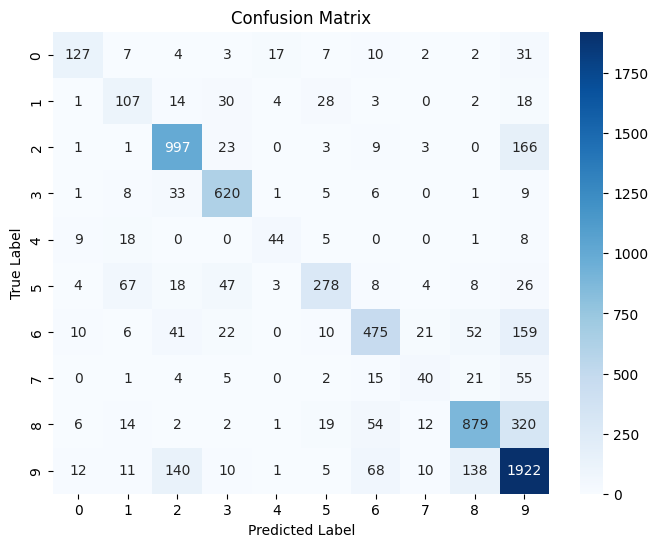


Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.60      0.67       210
           1       0.45      0.52      0.48       207
           2       0.80      0.83      0.81      1203
           3       0.81      0.91      0.86       684
           4       0.62      0.52      0.56        85
           5       0.77      0.60      0.67       463
           6       0.73      0.60      0.66       796
           7       0.43      0.28      0.34       143
           8       0.80      0.67      0.73      1309
           9       0.71      0.83      0.76      2317

    accuracy                           0.74      7417
   macro avg       0.69      0.64      0.65      7417
weighted avg       0.74      0.74      0.74      7417



In [ ]:
import torch
import numpy as np
import pandas as pd
from torchmetrics import Accuracy, Precision
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


accuracy = Accuracy(task="multiclass", num_classes=10).to('cuda')
precision = Precision(task="multiclass", num_classes=10).to('cuda')

#eval loop
model.eval()
accuracy.reset()
precision.reset()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        batch_X = batch_X.to('cuda')
        batch_y = batch_y.to('cuda')

        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1)

        accuracy.update(preds, batch_y)
        precision.update(preds, batch_y)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

overall_accuracy = accuracy.compute()
overall_precision = precision.compute()

print(f"Overall Accuracy: {overall_accuracy.item():.4f}")
print(f"Overall Precision: {overall_precision.item():.4f}")

from sklearn.metrics import f1_score, recall_score

f1 = f1_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')

print(f"F1 Score (Weighted): {f1:.4f}")
print(f"Recall (Weighted): {recall:.4f}")

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

In [31]:
from sklearn.metrics import precision_score, accuracy_score

precision = precision_score(all_labels, all_preds, average="weighted")
accuracy = accuracy_score(all_labels, all_preds)

print(f"Sklearn Precision: {precision:.4f}, Sklearn Accuracy: {accuracy:.4f}")

Sklearn Precision: 0.7414, Sklearn Accuracy: 0.7401


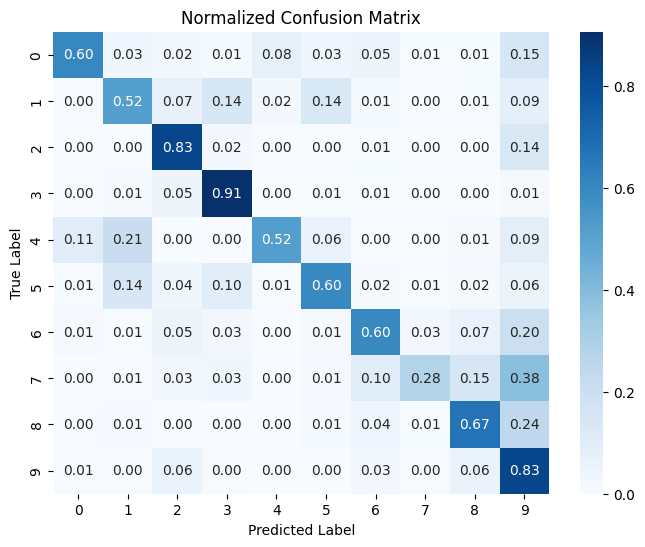

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(all_labels, all_preds)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

#plt
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix')
plt.show()

In [ ]:
#clean up
torch.cuda.empty_cache()
##majority vote loop

def majority_voting(preds_model1, preds_model2):
    combined_preds = np.stack((preds_model1, preds_model2), axis=1)
    
    final_preds = np.array([np.bincount(combined_preds[i]).argmax() for i in range(combined_preds.shape[0])])
    
    return final_preds

In [ ]:
accuracy = Accuracy(task="multiclass", num_classes=10).to('cuda')
precision = Precision(task="multiclass", num_classes=10).to('cuda')

#reset metrics
accuracy.reset()
precision.reset()

#store all preds and true labels
all_preds = []
all_labels = []

#eval loop
model.eval()
modelv2.eval()

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        batch_X = batch_X.to('cuda')
        batch_y = batch_y.to('cuda')

        #predictions from both
        outputs_model1 = model(batch_X)
        outputs_model2 = modelv2(batch_X)
        
        #in form argmax
        preds_model1 = torch.argmax(outputs_model1, dim=1).cpu().numpy()
        preds_model2 = torch.argmax(outputs_model2, dim=1).cpu().numpy()
        
        #apply majority
        final_preds = majority_voting(preds_model1, preds_model2)
        
        #update
        accuracy.update(torch.tensor(final_preds).to('cuda'), batch_y)
        precision.update(torch.tensor(final_preds).to('cuda'), batch_y)

        all_preds.extend(final_preds)
        all_labels.extend(batch_y.cpu().numpy())

In [ ]:

overall_accuracy = accuracy.compute()
overall_precision = precision.compute()

print(f"Majority Voting Accuracy: {overall_accuracy.item():.4f}")
print(f"Majority Voting Precision: {overall_precision.item():.4f}")

f1 = f1_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')

print(f"F1 Score (Weighted): {f1:.4f}")
print(f"Recall (Weighted): {recall:.4f}")


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Majority Voting)')
plt.show()

#Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix with Majority Voting')
plt.show()


Enseemble

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np

def get_model_predictions(models, dataloader):
    model_preds = []
    all_labels = []  

    for model in models:
        model.eval()
        preds_list = []

        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs = inputs.to('cuda')
                outputs = model(inputs)
                preds = F.softmax(outputs, dim=1)
                preds_list.append(preds.cpu().numpy())

                if model == models[0]: 
                    all_labels.extend(labels.numpy())

        model_preds.append(np.concatenate(preds_list, axis=0))

    stacked_preds = np.array(model_preds).transpose(1, 0, 2)  # shape (num_samples, num_models, num_classes)
    return stacked_preds, np.array(all_labels)

In [ ]:
models = [model, modelv2]
base_model_predictions, y_true = get_model_predictions(models, val_loader)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

#flatten predictions to features
X_meta = base_model_predictions.reshape(base_model_predictions.shape[0], -1)  # Shape (num_samples, num_models * num_classes)
y_meta = np.array(labels_val)  #use val labels

#train logistic regression model
X_train, X_val, y_train, y_val = train_test_split(X_meta, y_meta, test_size=0.2, random_state=42)

meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(X_train, y_train)

In [ ]:
#evaluate meta-model
meta_model_accuracy = meta_model.score(X_val, y_val)
print(f"Meta-model accuracy: {meta_model_accuracy * 100:.2f}%")
def predict_with_stacking(models, meta_model, dataloader):

    base_preds, y_truth = get_model_predictions(models, dataloader) #detuple  
    
    X_meta = base_preds.reshape(base_preds.shape[0], -1) 

    final_preds = meta_model.predict(X_meta)

    
    return final_preds, y_true


final_preds, y_true = predict_with_stacking(models, meta_model, val_loader)

In [ ]:
final_labels = y_true

if len(final_preds) == len(final_labels):
    
    acc = accuracy_score(final_labels, final_preds)
    print(f"Accuracy: {acc:.4f}")


    precision = precision_score(final_labels, final_preds, average='weighted')
    recall = recall_score(final_labels, final_preds, average='weighted')
    f1 = f1_score(final_labels, final_preds, average='weighted')

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    cm = confusion_matrix(final_labels, final_preds)
    print("Confusion Matrix:")
    print(cm)

    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(final_labels), yticklabels=np.unique(final_labels))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    #normalized 
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=np.arange(10), yticklabels=np.arange(10))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Normalized Confusion Matrix')
    plt.show()

else:
    print("Error: Mismatch between number of predictions and true labels!")

In [ ]:
import joblib
joblib.dump(meta_model, "ensemble_model.joblib")